[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brianjalaian/CAP6606_ML_ISR/blob/main/modules/16_rl/RL-LectureCode.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/brianjalaian/CAP6606_ML_ISR/blob/main/modules/16_rl/RL-LectureCode.ipynb)


# Chapter 19 - Reinforcement Learning for Decision Making in Complex Environments

In [1]:
from IPython.display import Image
%matplotlib inline

## Implementing our first RL algorithm

### Working with the existing environments in OpenAI Gym

**Purpose of This Section**
- Demonstrates how to **implement Q-learning** to solve a grid-world task.
- Uses **OpenAI Gym** environments to provide a practical RL simulation framework.
- Focuses on **tabular Q-learning**, the most basic model-free RL method.


**Introducing OpenAI Gym Toolkit**
- **OpenAI Gym**: A library of environments for benchmarking RL algorithms.
- Includes environments from simple to complex (e.g., `CartPole`, `MountainCar`, robotics).
- Gym provides:
  - A **unified API** for agent-environment interaction.
  - Tools for rendering and stepping through environments.

In [3]:
# !pip install gym

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.7/721.7 kB 22.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for gym: filename=gym-0.26.2-py3-none-any.whl size=827745 sha256=4d987f726634dfbd8a8da8912681f3deb5a534e4e190767b465f9daa6e208361
  Stored in directory: /tmp/pip-ephem-wheel-cache-nxita8rx/wheels/b9/22/6d/3e7b32d98451b4cd9d12417052affbeeeea012955d437da1da
Successfully built gym


**Working with Gym Environments**
- Use `gym.make(env_name)` to load an environment.
- Common API methods:
  - `env.reset()` — initializes a new episode, returns initial observation.
  - `env.step(action)` — executes an action, returns:
    - `next_state`, `reward`, `done`, `info`
  - `env.render()` — (optional) visualizes the environment state.
- Spaces:
  - `env.observation_space` — defines state format (e.g., `Box`)
  - `env.action_space` — defines possible actions (e.g., `Discrete`)


**The Environment: CartPole-v1**
- Classic RL task where a **cart must balance a pole** using left/right moves.
- States (`Box(4,)`): Continuous vector of 4 values (cart position, velocity, pole angle, and pole tip's velocity) for min and max each
- Actions: `0` (move left), `1` (move right)


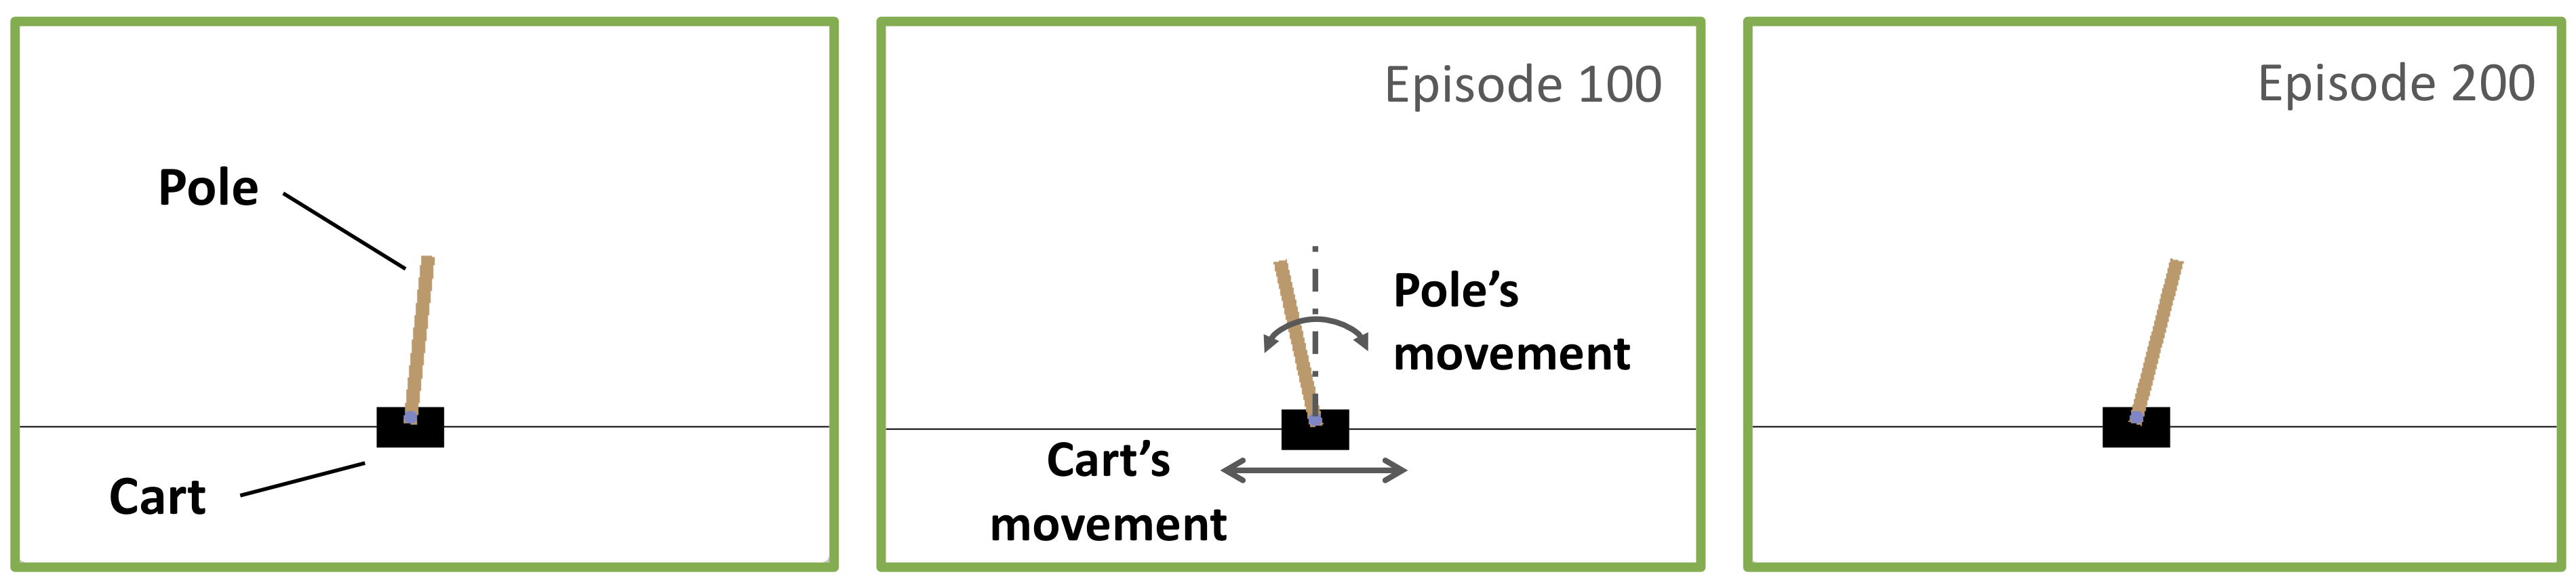

In [ ]:
Image(filename='figures/19_06.png', width=600)

In [4]:
import gym  

env = gym.make('CartPole-v1')  
env.observation_space

Box([-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38], [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38], (4,), float32)

In [5]:
env.action_space

Discrete(2)

In [6]:
# Set the pole’s starting state (S0)
env.reset()

(array([-0.00863925,  0.02971761, -0.02400191, -0.04376195], dtype=float32),
 {})

Every time we call `env.step()`, it returns:
- An array for the new state (or observations)  
- A reward (a scalar value of type `float`)  
- A termination flag (`True` or `False`)  
- A Python dictionary containing auxiliary information

In [7]:
# Push the cart to the left
env.step(action=0)

(array([-0.00804489, -0.16505209, -0.02487715,  0.24125256], dtype=float32),
 1.0,
 False,
 False,
 {})

### A grid world example

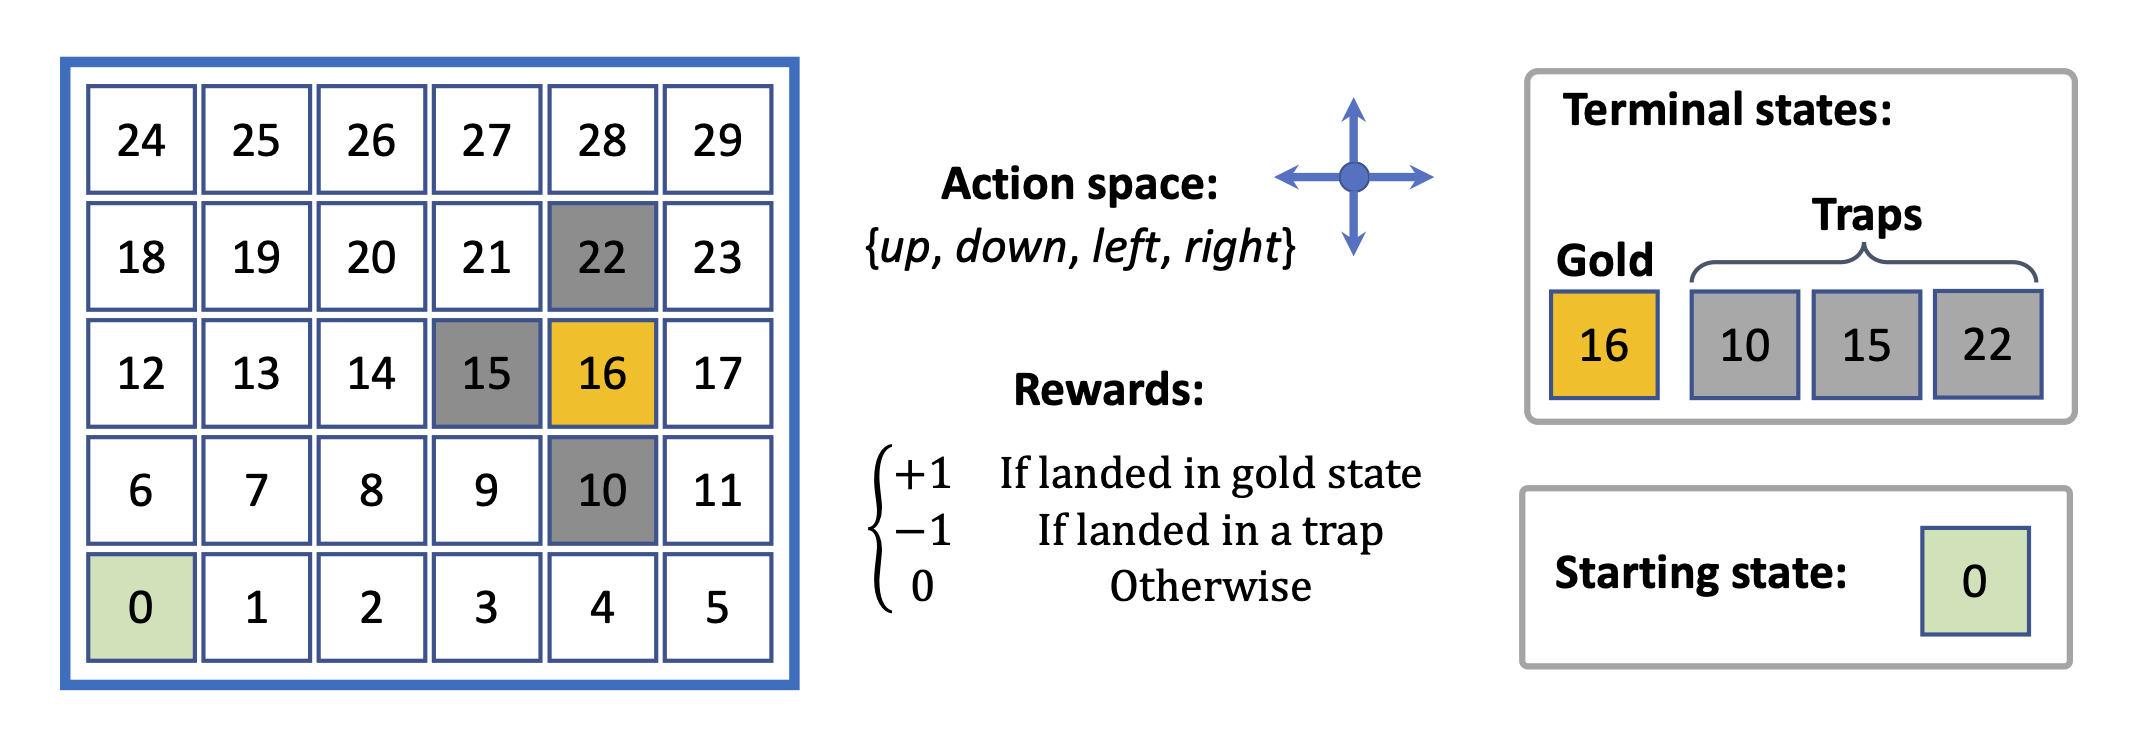

In [13]:
Image(filename='figures/19_07.png', width=600)

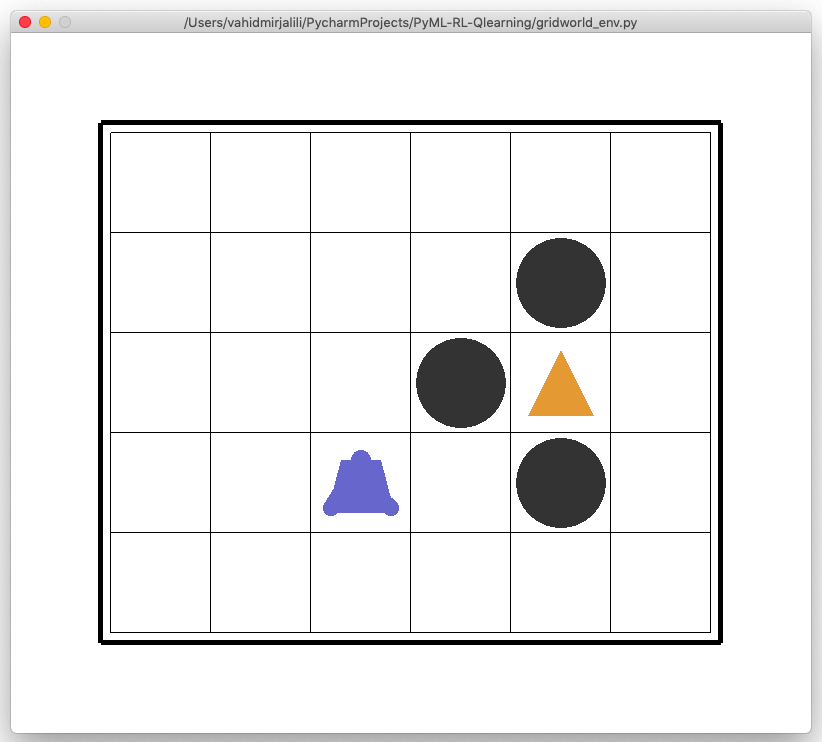

In [ ]:
Image(filename='figures/19_08.png', width=600)

/tmp/ipykernel_34168/3032829683.py:243: MatplotlibDeprecationWarning: Passing the radius parameter of __init__() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  goal = patches.RegularPolygon((gc + 0.5, gr + 0.5), 3, 0.4, color='gold')


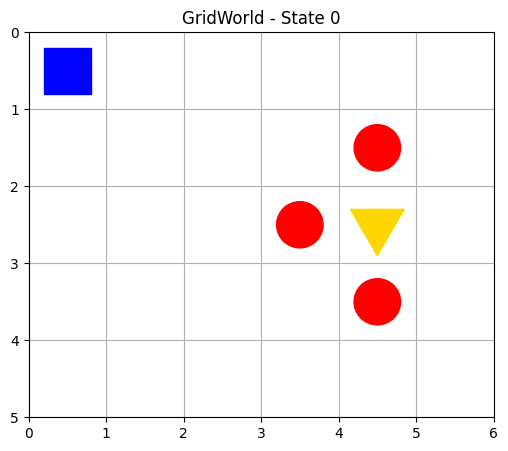

Action: 3, New State: 0, Reward: 0.0


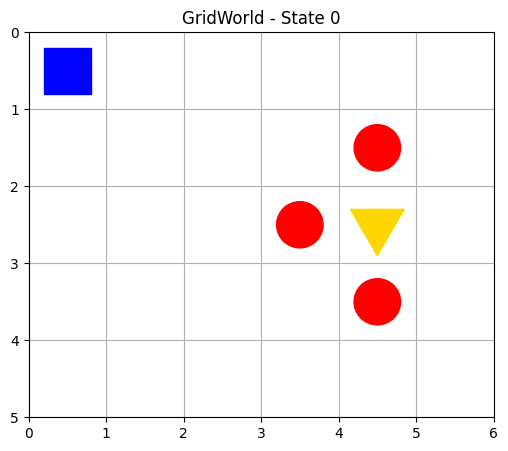

Action: 1, New State: 1, Reward: 0.0


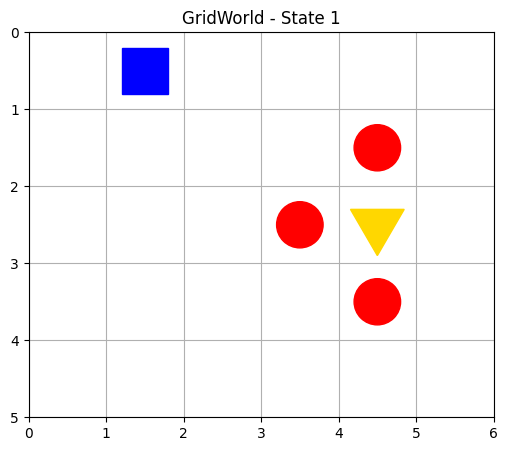

Action: 2, New State: 7, Reward: 0.0


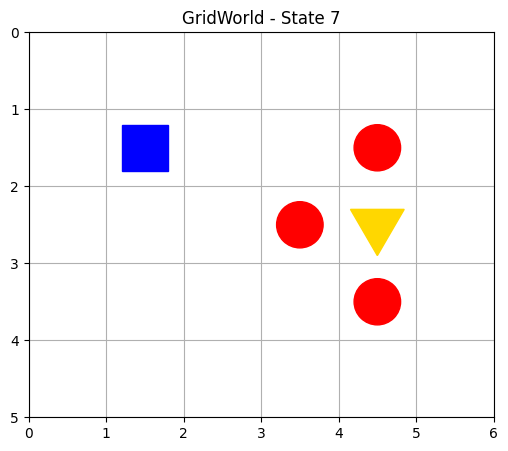

Action: 0, New State: 1, Reward: 0.0


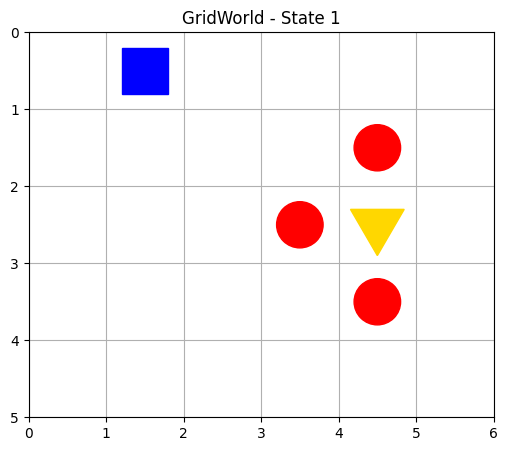

Action: 1, New State: 2, Reward: 0.0


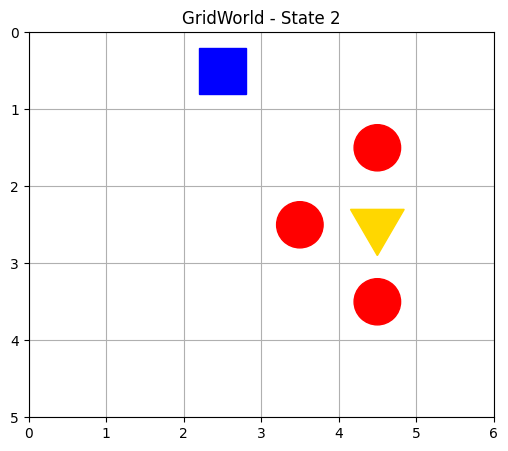

Action: 0, New State: 2, Reward: 0.0


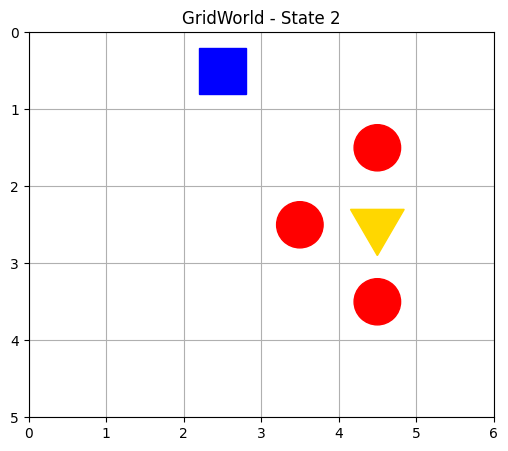

Action: 0, New State: 2, Reward: 0.0


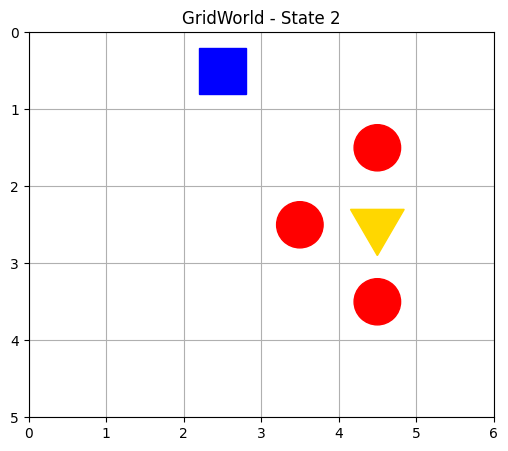

Action: 2, New State: 8, Reward: 0.0


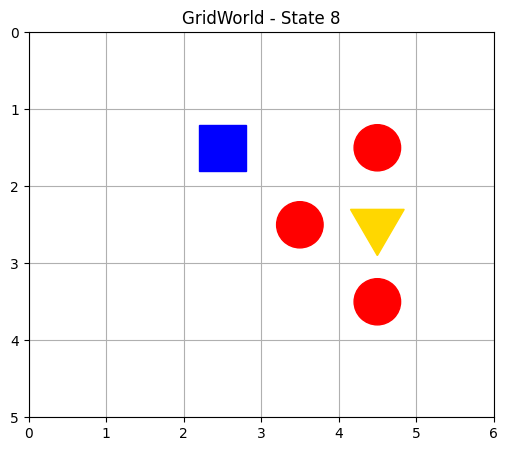

Action: 1, New State: 9, Reward: 0.0


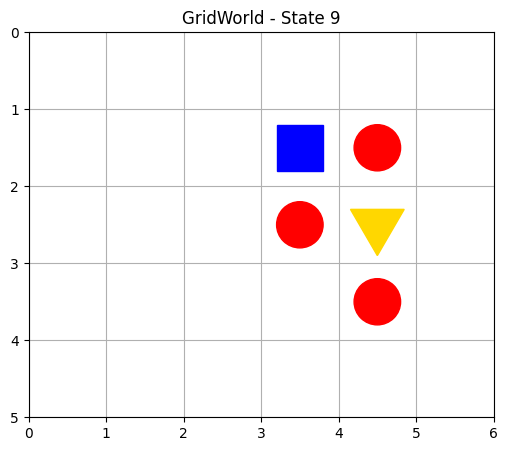

Action: 1, New State: 10, Reward: -1.0


In [16]:
# gridworld_env.py
# Custom GridWorld environment - modernized for newer Gym
# Based on code from "Python Machine Learning, PyTorch Edition" (Raschka et al.)

import numpy as np
import gym
from gym import spaces
from collections import defaultdict
import time
import os
import pickle
# Visualization by matplotlib if built-in rendering is unavailable
import matplotlib.pyplot as plt
import matplotlib.patches as patches

try:
    from gym.envs.classic_control import rendering  # Classic gym
except ImportError:
    rendering = None  # Safe fallback for headless/Colab environments

CELL_SIZE = 100
MARGIN = 10


# Utility to get cell coordinates
def get_coords(row, col, loc='center'):
    xc = (col + 1.5) * CELL_SIZE
    yc = (row + 1.5) * CELL_SIZE

    if loc == 'center':
        return xc, yc
    elif loc == 'interior_corners':
        half = CELL_SIZE // 2 - MARGIN
        xl, xr = xc - half, xc + half
        yt, yb = yc - half, yc + half
        return [(xl, yt), (xr, yt), (xr, yb), (xl, yb)]
    elif loc == 'interior_triangle':
        return [
            (xc, yc + CELL_SIZE // 3),
            (xc + CELL_SIZE // 3, yc - CELL_SIZE // 3),
            (xc - CELL_SIZE // 3, yc - CELL_SIZE // 3),
        ]


# Utility to draw visual elements
def draw_object(coords_list):
    if rendering is None:
        return None

    if len(coords_list) == 1:  # circle
        obj = rendering.make_circle(int(0.45 * CELL_SIZE))
        transform = rendering.Transform()
        obj.add_attr(transform)
        transform.set_translation(*coords_list[0])
        obj.set_color(0.2, 0.2, 0.2)
    elif len(coords_list) == 3:  # triangle
        obj = rendering.FilledPolygon(coords_list)
        obj.set_color(0.9, 0.6, 0.2)
    else:  # polygon
        obj = rendering.FilledPolygon(coords_list)
        obj.set_color(0.4, 0.4, 0.8)

    return obj


class GridWorldEnv(gym.Env):
    """
    Custom GridWorld environment for simple reinforcement learning experiments.
    Grid contains:
    - Agent (starts at top-left)
    - Gold (goal, +1 reward)
    - Traps (fail states, -1 reward)
    """
    metadata = {"render_modes": ["human", "rgb_array"]}

    def __init__(self, num_rows=4, num_cols=6, delay=0.05):
        super().__init__()

        self.num_rows = num_rows
        self.num_cols = num_cols
        self.nS = num_rows * num_cols
        self.nA = 4  # up, right, down, left
        self.delay = delay

        self.action_space = spaces.Discrete(self.nA)
        self.observation_space = spaces.Discrete(self.nS)

        # Mapping between state index and grid positions
        self.grid2state = {(r, c): r * num_cols + c for r in range(num_rows) for c in range(num_cols)}
        self.state2grid = {v: k for k, v in self.grid2state.items()}

        # Goal and traps
        self.gold_cell = (num_rows // 2, num_cols - 2)
        self.trap_cells = [
            (self.gold_cell[0] + 1, self.gold_cell[1]),
            (self.gold_cell[0], self.gold_cell[1] - 1),
            (self.gold_cell[0] - 1, self.gold_cell[1])
        ]
        self.terminal_states = [self.grid2state[self.gold_cell]] + [self.grid2state[c] for c in self.trap_cells]

        # Initial state
        self.start_state = 0
        self.state = self.start_state

        # Transition model (deterministic)
        self.P = self._build_transition_model()

        # Viewer for rendering
        self.viewer = None
        if rendering is not None:
            self._build_display()
    
    # Build the transition probability
    def _build_transition_model(self):
        P = defaultdict(dict)

        for s in range(self.nS):
            row, col = self.state2grid[s]
            P[s] = defaultdict(list)

            for a in range(self.nA):
                new_row, new_col = row, col
                if a == 0: new_row = max(0, row - 1)       # up
                elif a == 1: new_col = min(self.num_cols - 1, col + 1)  # right
                elif a == 2: new_row = min(self.num_rows - 1, row + 1)  # down
                elif a == 3: new_col = max(0, col - 1)     # left

                next_state = self.grid2state[(new_row, new_col)]
                reward = 0.0
                done = False

                if next_state in self.terminal_states:
                    reward = 1.0 if next_state == self.grid2state[self.gold_cell] else -1.0
                    done = True

                if s in self.terminal_states:
                    # Terminal state is absorbing
                    P[s][a] = [(1.0, s, 0.0, True)]
                else:
                    P[s][a] = [(1.0, next_state, reward, done)]
        return P

    def reset(self, seed=None, options=None):
        self.state = self.start_state
        return self.state, {}

    # Agent takes a step (action)
    def step(self, action):
        transitions = self.P[self.state][action]
        prob, next_state, reward, done = transitions[0]
        self.state = next_state
        return next_state, reward, done, False, {}

    def is_terminal(self, s):
        return s in self.terminal_states

    def _build_display(self):
        screen_w = (self.num_cols + 2) * CELL_SIZE
        screen_h = (self.num_rows + 2) * CELL_SIZE
        self.viewer = rendering.Viewer(screen_w, screen_h)

        elements = []

        # Grid border
        border_coords = [
            (CELL_SIZE - MARGIN, CELL_SIZE - MARGIN),
            (screen_w - CELL_SIZE + MARGIN, CELL_SIZE - MARGIN),
            (screen_w - CELL_SIZE + MARGIN, screen_h - CELL_SIZE + MARGIN),
            (CELL_SIZE - MARGIN, screen_h - CELL_SIZE + MARGIN)
        ]
        border = rendering.PolyLine(border_coords, True)
        border.set_linewidth(5)
        elements.append(border)

        # Grid lines
        for col in range(self.num_cols + 1):
            x = (col + 1) * CELL_SIZE
            line = rendering.PolyLine([(x, CELL_SIZE), (x, (self.num_rows + 1) * CELL_SIZE)], False)
            elements.append(line)
        for row in range(self.num_rows + 1):
            y = (row + 1) * CELL_SIZE
            line = rendering.PolyLine([(CELL_SIZE, y), ((self.num_cols + 1) * CELL_SIZE, y)], False)
            elements.append(line)

        # Traps
        for cell in self.trap_cells:
            coords = get_coords(*cell, loc='center')
            elements.append(draw_object([coords]))

        # Gold
        coords = get_coords(*self.gold_cell, loc='interior_triangle')
        elements.append(draw_object(coords))

        # Agent
        if os.path.exists('robot-coordinates.pkl') and CELL_SIZE == 100:
            agent_coords = pickle.load(open('robot-coordinates.pkl', 'rb'))
            agent_coords += np.array(get_coords(0, 0, loc='center'))
        else:
            agent_coords = get_coords(0, 0, loc='interior_corners')
        agent = draw_object(agent_coords)
        self.agent_trans = rendering.Transform()
        agent.add_attr(self.agent_trans)
        elements.append(agent)

        for obj in elements:
            self.viewer.add_geom(obj)

    def render(self, mode='human'):
        if rendering is None:
            print("[Rendering not available in this environment]")
            return

        x, y = self.state2grid[self.state]
        x_coord = (x + 1.5) * CELL_SIZE
        y_coord = (y + 1.5) * CELL_SIZE
        self.agent_trans.set_translation(y_coord, x_coord)

        frame = self.viewer.render(return_rgb_array=(mode == 'rgb_array'))
        time.sleep(self.delay)
        return frame

    def close(self):
        if self.viewer:
            self.viewer.close()
            self.viewer = None

    def render_matplotlib(self):
        fig, ax = plt.subplots(figsize=(self.num_cols, self.num_rows))
        ax.set_xlim(0, self.num_cols)
        ax.set_ylim(0, self.num_rows)
        ax.set_xticks(range(self.num_cols + 1))
        ax.set_yticks(range(self.num_rows + 1))
        ax.grid(True)
        ax.invert_yaxis()  # Make (0, 0) top-left like in your logic

        # Draw traps
        for r, c in self.trap_cells:
            trap = patches.Circle((c + 0.5, r + 0.5), 0.3, color='red')
            ax.add_patch(trap)

        # Draw goal
        gr, gc = self.gold_cell
        goal = patches.RegularPolygon((gc + 0.5, gr + 0.5), 3, 0.4, color='gold')
        ax.add_patch(goal)

        # Draw agent
        ar, ac = self.state2grid[self.state]
        agent = patches.Rectangle((ac + 0.2, ar + 0.2), 0.6, 0.6, color='blue')
        ax.add_patch(agent)

        ax.set_title(f"GridWorld - State {self.state}")
        plt.show()
        

if __name__ == "__main__":
    env = GridWorldEnv(5, 6)

    obs, _ = env.reset()
    done = False
    while not done:
        # env.render()
        env.render_matplotlib()

        action = env.action_space.sample()
        obs, reward, done, truncated, info = env.step(action)
        print(f"Action: {action}, New State: {obs}, Reward: {reward}")

    env.close()

### Solving a grid world problem with Q-learning

In [17]:
# agent.py
# Q-Learning Agent for GridWorld
# Adapted from Python Machine Learning, PyTorch Edition (Raschka et al.)

from collections import defaultdict
import numpy as np


class Agent:
    def __init__(
        self, env,
        learning_rate=0.1,
        discount_factor=0.95,
        epsilon_greedy=1.0,
        epsilon_min=0.1,
        epsilon_decay=0.99
    ):
        """
        Q-learning agent
        """
        self.env = env
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon_greedy
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay

        # Q-table: maps state to action values
        self.q_table = defaultdict(lambda: np.zeros(self.env.nA))

    def choose_action(self, state):
        """
        Epsilon-greedy action selection
        """
        if np.random.uniform() < self.epsilon:
            return np.random.choice(self.env.nA)  # Explore
        else:
            q_vals = self.q_table[state]
            # Break ties randomly
            best_actions = np.flatnonzero(q_vals == q_vals.max())
            return np.random.choice(best_actions)

    def learn(self, transition):
        """
        Q-Learning update
        """
        s, a, r, next_s, done = transition
        current_q = self.q_table[s][a]

        if done:
            target = r
        else:
            target = r + self.gamma * np.max(self.q_table[next_s])

        self.q_table[s][a] += self.lr * (target - current_q)

        # Decay epsilon (less greedy exploration after agent gradually find the optimal path)
        self._adjust_epsilon()

    def _adjust_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

Episode 1: Moves = 10, Reward = -1.00, Epsilon = 0.904
Episode 2: Moves = 60, Reward = -1.00, Epsilon = 0.495
Episode 3: Moves = 18, Reward = -1.00, Epsilon = 0.413
Episode 4: Moves = 28, Reward = -1.00, Epsilon = 0.312
Episode 5: Moves = 6, Reward = -1.00, Epsilon = 0.293
Episode 6: Moves = 48, Reward = -1.00, Epsilon = 0.181
Episode 7: Moves = 43, Reward = -1.00, Epsilon = 0.118
Episode 8: Moves = 149, Reward = -1.00, Epsilon = 0.099
Episode 9: Moves = 13, Reward = -1.00, Epsilon = 0.099
Episode 10: Moves = 135, Reward = -1.00, Epsilon = 0.099
Episode 11: Moves = 173, Reward = -1.00, Epsilon = 0.099
Episode 12: Moves = 42, Reward = -1.00, Epsilon = 0.099
Episode 13: Moves = 13, Reward = -1.00, Epsilon = 0.099
Episode 14: Moves = 427, Reward = 1.00, Epsilon = 0.099
Episode 15: Moves = 50, Reward = -1.00, Epsilon = 0.099
Episode 16: Moves = 264, Reward = -1.00, Epsilon = 0.099
Episode 17: Moves = 43, Reward = -1.00, Epsilon = 0.099
Episode 18: Moves = 115, Reward = -1.00, Epsilon = 0.0

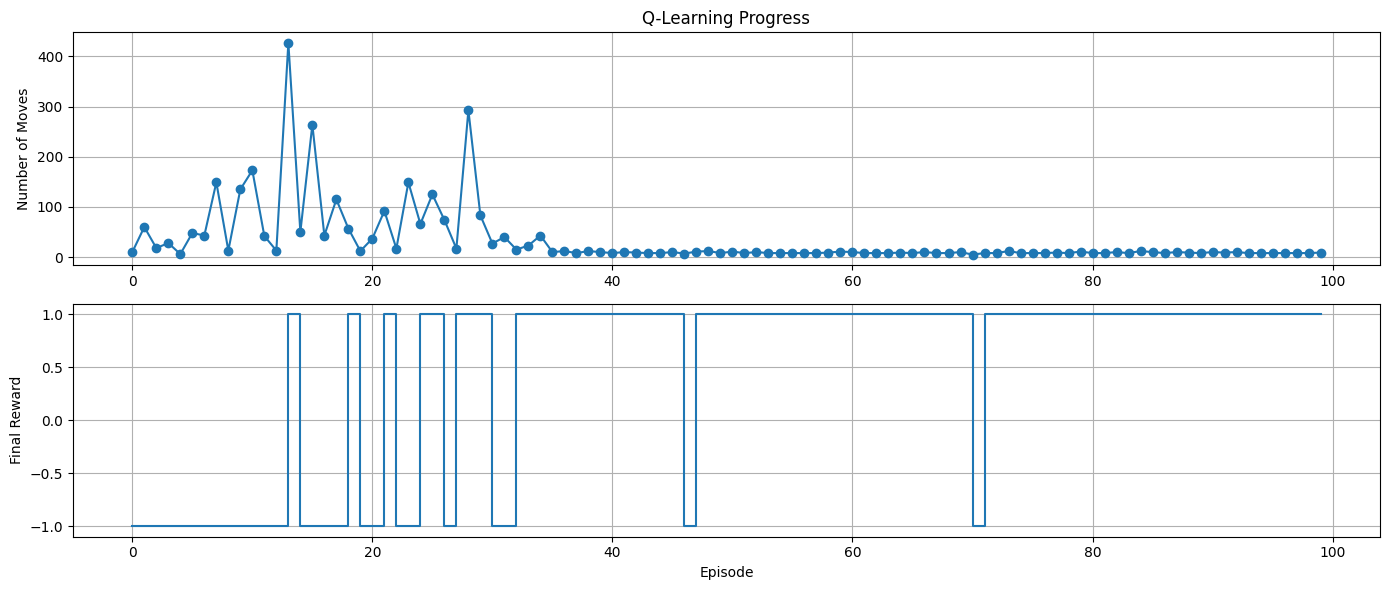

In [18]:
# qlearning.py
# Q-Learning on GridWorld Environment (in previous code block)

from collections import namedtuple
import matplotlib.pyplot as plt
import numpy as np

# For reproducibility
np.random.seed(1)

# Named tuple for transitions
Transition = namedtuple('Transition', ['state', 'action', 'reward', 'next_state', 'done'])


def run_qlearning(agent, env, num_episodes=100, visualize=False):
    """
    Run Q-learning over multiple episodes
    Returns: history list with (num_moves, final_reward) per episode
    """
    history = []

    for episode in range(num_episodes):
        state, _ = env.reset()
        done = False
        total_reward, n_moves = 0.0, 0

        while not done:
            if visualize:
                env.render_matplotlib()

            action = agent.choose_action(state)
            next_state, reward, done, truncated, _ = env.step(action)

            # Learning step
            agent.learn(Transition(state, action, reward, next_state, done))
            state = next_state
            total_reward += reward
            n_moves += 1

        history.append((n_moves, total_reward))
        print(f"Episode {episode+1}: Moves = {n_moves}, Reward = {total_reward:.2f}, Epsilon = {agent.epsilon:.3f}")

    return history


def plot_learning_history(history):
    """
    Plot training history: number of steps and rewards
    """
    episodes = np.arange(len(history))
    moves = [h[0] for h in history]
    rewards = [h[1] for h in history]

    plt.figure(figsize=(14, 6))

    # Moves plot
    plt.subplot(2, 1, 1)
    plt.plot(episodes, moves, marker='o')
    plt.title("Q-Learning Progress")
    plt.ylabel("Number of Moves")
    plt.grid(True)

    # Rewards plot
    plt.subplot(2, 1, 2)
    plt.plot(episodes, rewards, drawstyle='steps-post')
    plt.xlabel("Episode")
    plt.ylabel("Final Reward")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    env = GridWorldEnv(num_rows=5, num_cols=6)
    agent = Agent(env)

    history = run_qlearning(agent, env, num_episodes=100, visualize=False)
    env.close()

    plot_learning_history(history)

**Top plot**

The agent is learning how to reach the goal quickly, and over time, it reduces randomness by exploiting known good paths.
- **Episodes 0–30**: High variance — the agent is exploring a lot, sometimes hitting traps, sometimes wandering.
- **Episodes ~30 onward**: Steady drop to ~10–20 moves. This is exactly what you want — it’s a sign the agent has learned the optimal or near-optimal path and is executing it consistently.

**Bottom plot**

The agent is initially bad (as expected), then improves, and finally consistently reaches the goal without hitting traps.
- First 10–15 episodes: Mostly -1 rewards — hitting traps.
- Then intermittent 1/-1 rewards: Agent is learning, testing actions, sometimes gets the gold.
- After ~30–35: Mostly consistent +1 rewards.


## A glance at deep Q-learning

### Problems in Tabular Q-learning
**Limitations of Tabular Q-learning**
- Previous example used a **discrete state space of size 30**.
- Q-values were stored in a **Python dictionary** — feasible for small, finite MDPs.

**Problems with Tabular Methods**
- **Large or continuous state spaces** make tabular representation intractable.
- **Infinite or near-infinite states** cannot be individually stored.
- **Sparse visitation**: some states might **never be visited**, making generalization difficult.


**Solution: Function Approximation**
- Replace tabular value functions with **parametric functions**:
  - Instead of $V(S_t)$ or $Q(S_t, A_t)$, use:
    - $v_w(x_s)$ to approximate $v_\pi(s)$
    - $q_w(x_s, a)$ to approximate $q_\pi(s, a)$
- Here:
  - $w$: parameters (e.g., weights of a neural network)
  - $x_s$: **featurized representation** of state $s$


### Deep Q-Networks (DQN)
- A **deep Q-network (DQN)** is when $q_w(x_s, a)$ is modeled using a **deep neural network (DNN)**.
- The DNN takes the state (or its features) as input and outputs **Q-values** for each possible action.

**Training DQN**
- Q-values are updated using the **Q-learning update rule** (we've seen in the lecture). One modification is in the agent’s `choose_action()` method, which, in the code of the previous section for Q-learning, was simply accessing the action values stored in a dictionary. Now, this function should be changed to perform a **forward pass of the NN model** for computing the action values.

**Key Insight**
- DQN allows agents to generalize across **unseen states** by learning from features.
- Makes RL feasible in **complex, high-dimensional, or continuous environments** where tabular methods fail.


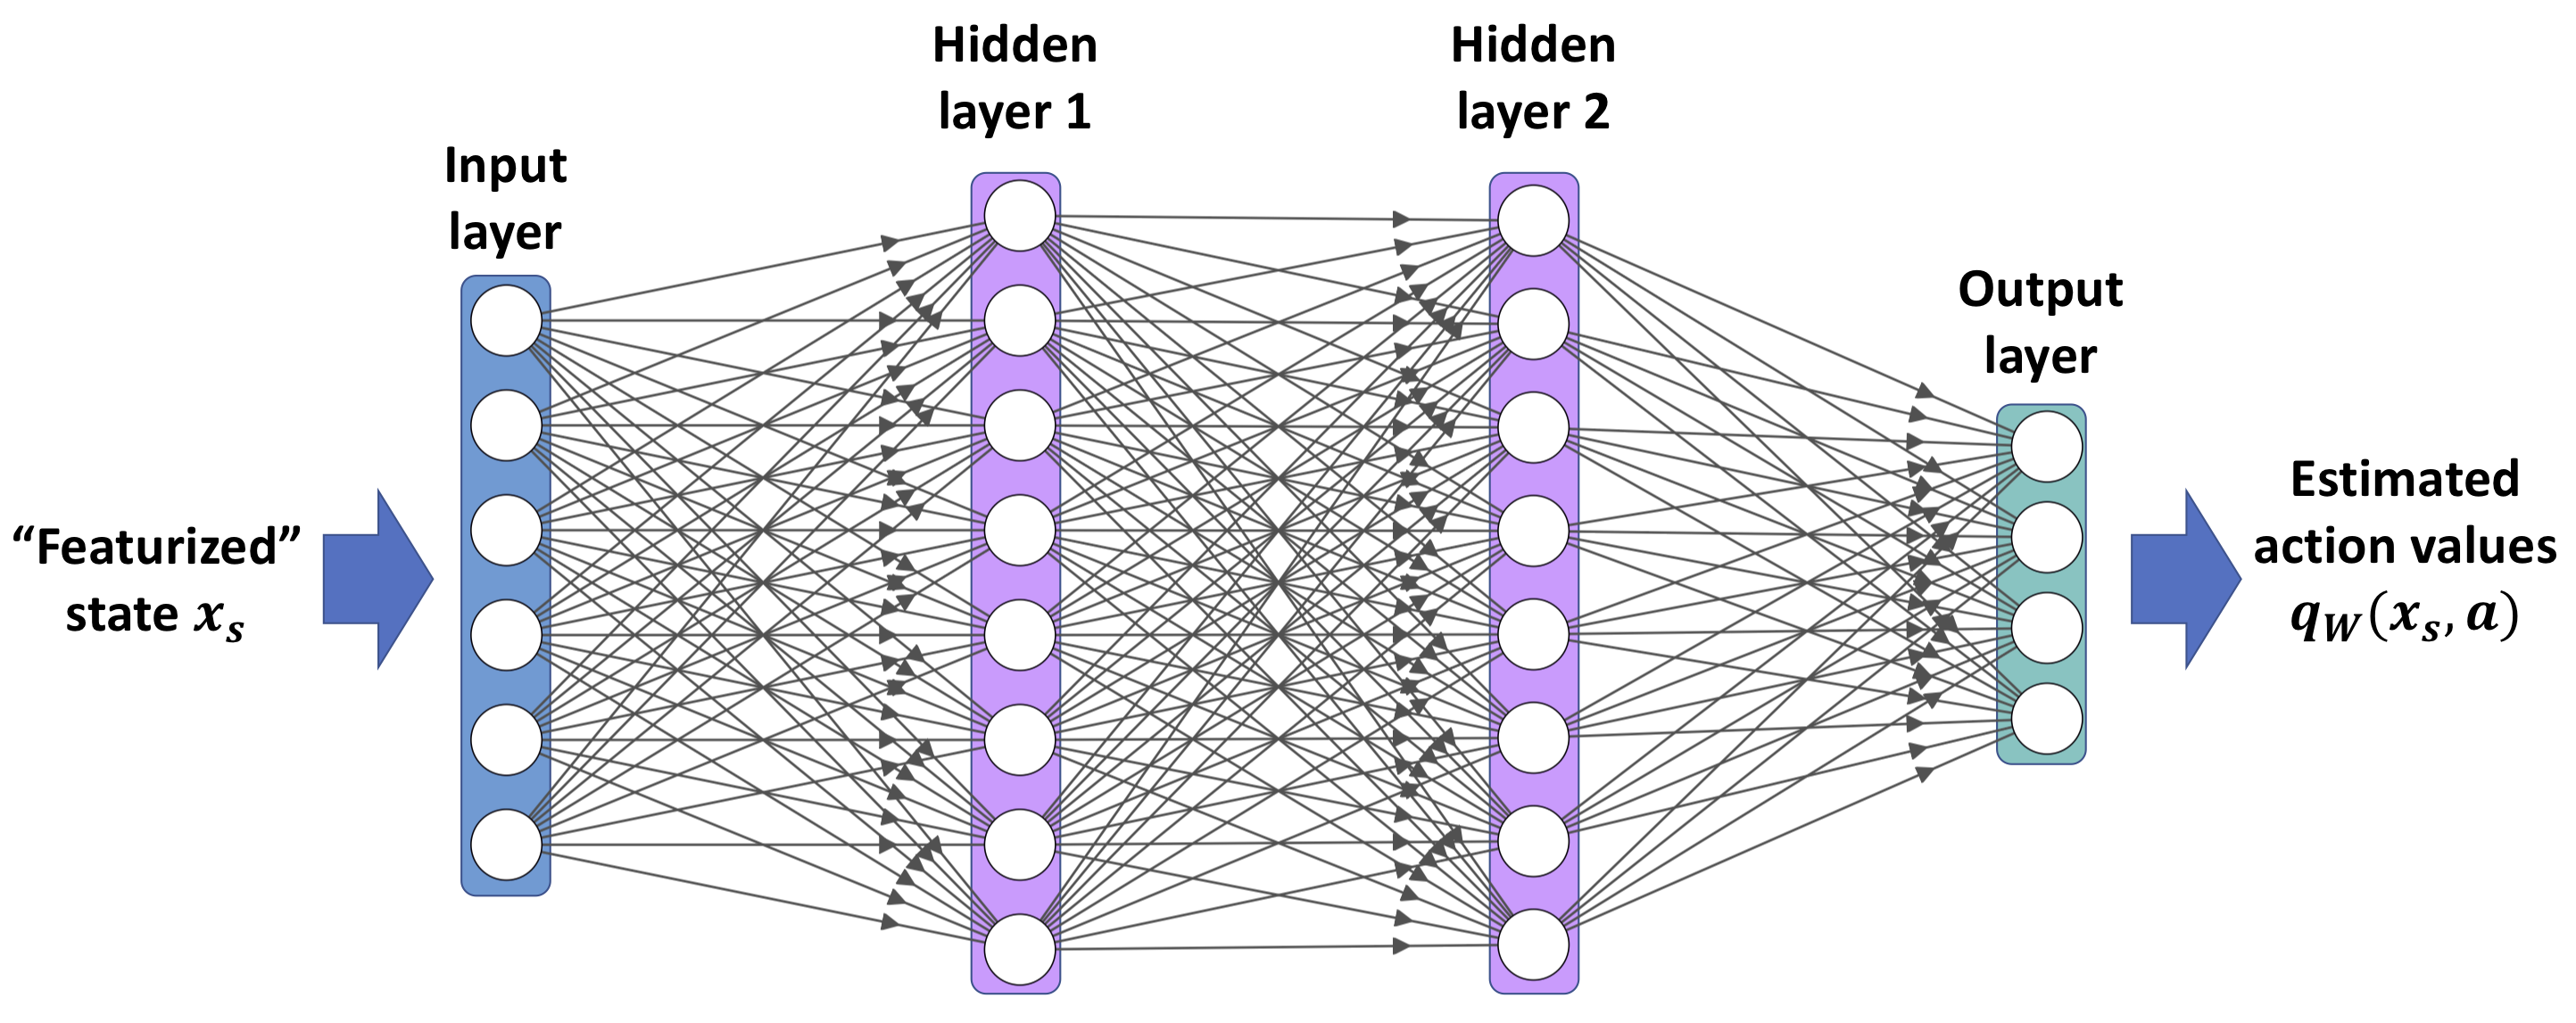

In [ ]:
Image(filename='figures/19_10.png', width=600)

### DQN: Replay memory

**Challenges with Neural Network Approximation**
1. Interference Between Updates:
	- In tabular Q-learning, updating a value for a specific state-action pair doesn’t affect others.
	- With a neural network, updating the weights to fit one state-action pair $(s, a)$ affects outputs for other states as well.
2. Changing Distribution of States:
	- In supervised learning, multiple epochs can be used to train on a fixed dataset.
	- In Q-learning, the environment is non-stationary: as the agent learns, it visits different states, making older samples less relevant or less likely to reoccur.
3. Lack of IID Assumption:
	- Neural networks assume training samples are IID (independent and identically distributed).
	- In reinforcement learning, transitions $(s_t, a_t, r_t, s_{t+1})$ are sequential and correlated, violating the IID assumption.


To address these issues, **replay memory** (also known as **experience replay**) is introduced.

**Transition Storage**
- As the agent interacts with the environment, it generates transition quintuples: $q_v(x_s, a) = (s_t, a_t, r_t, s_{t+1}, \text{done})$

(These transitions are stored in a finite-sized buffer.)

**Buffer Management**
- The memory buffer is often implemented as a list or queue.
- When the buffer is full, the oldest transition is removed to make room for the new one: `memory.pop(0)`


**Sampling and Training**
- Instead of training on the most recent transition, the network trains on mini-batches randomly sampled from the buffer
  	- Breaks the correlation between samples.
  	- Helps with better generalization and stability of learning.



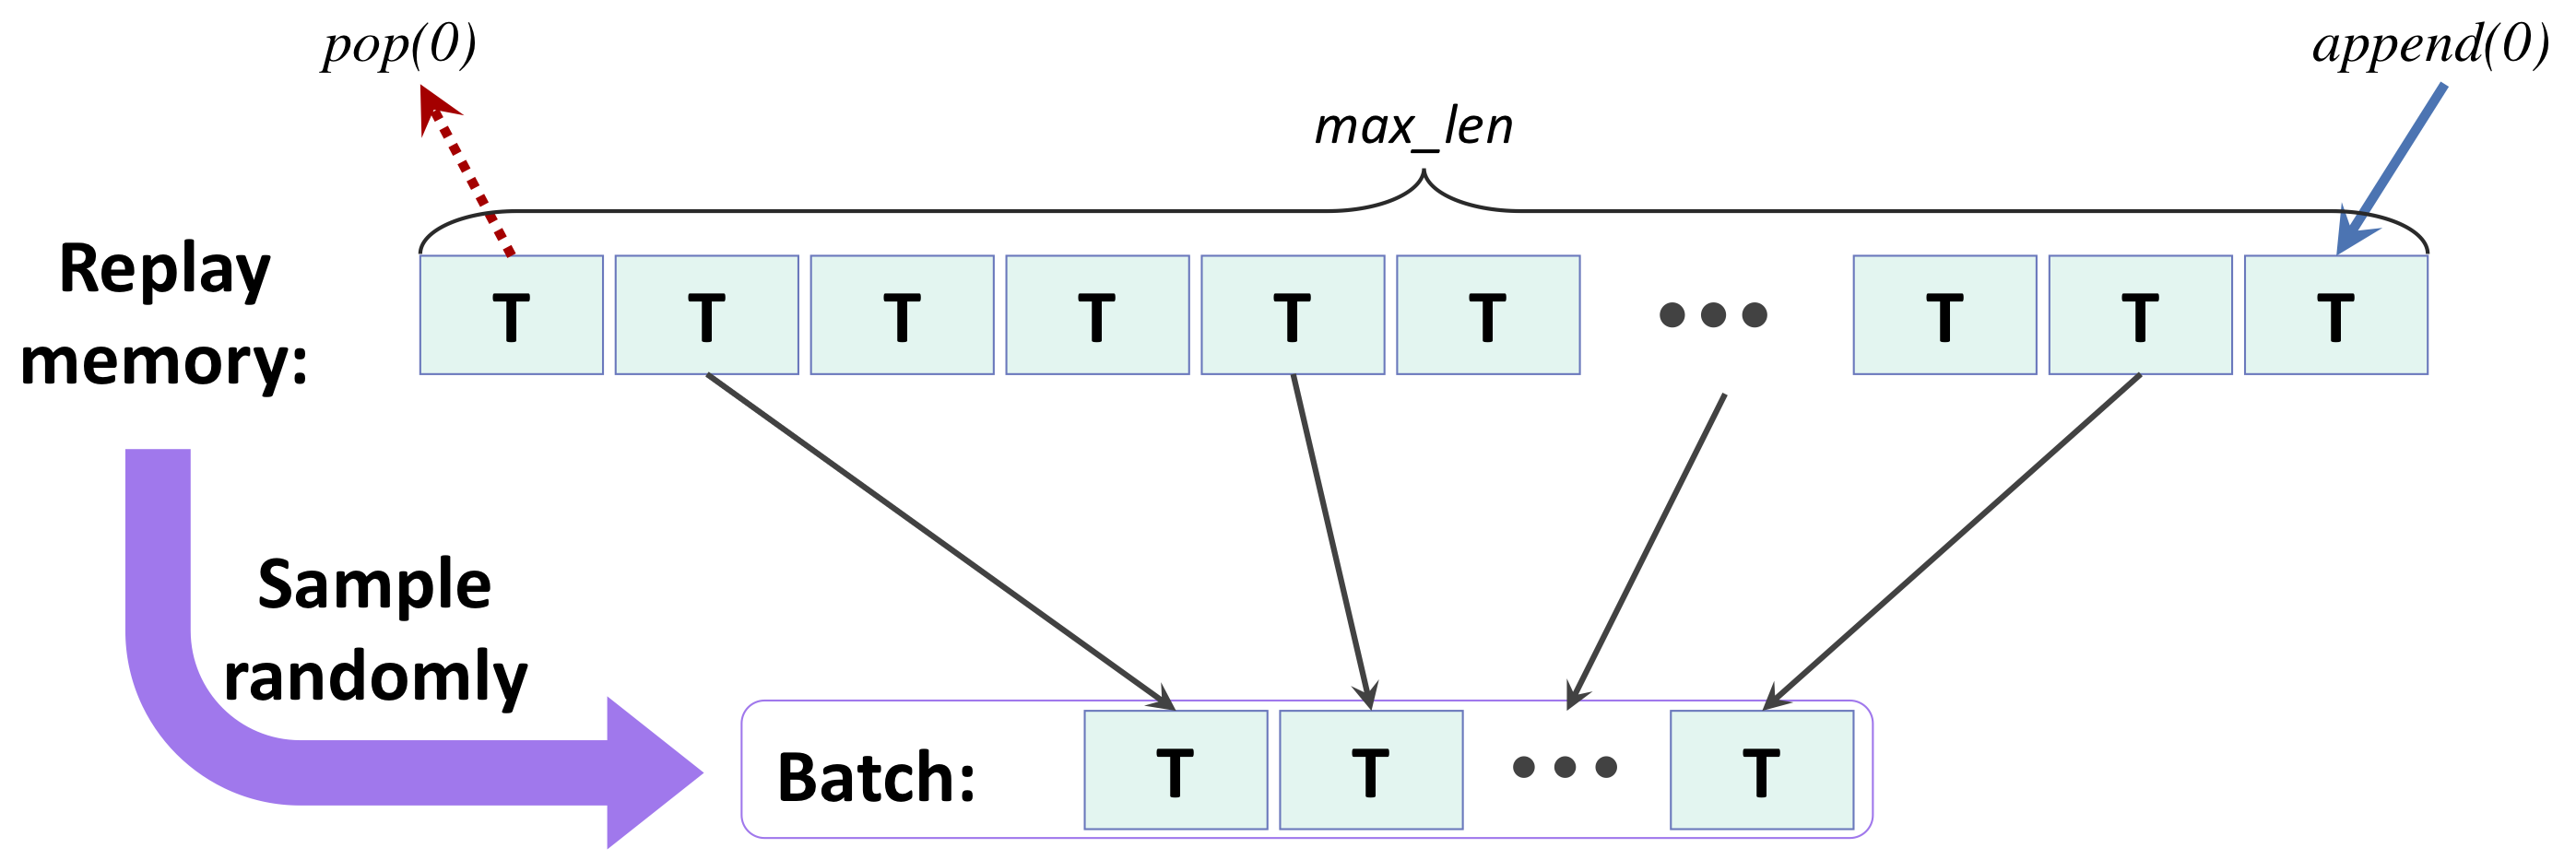

In [16]:
Image(filename='figures/19_11.png', width=600)

### Determining the Target Values for Computing the Loss in DQN

To train a Deep Q-Network (DQN), we need to adapt the update rule from tabular Q-learning to work with neural networks. This involves how we compute the target values used to calculate the loss.

**Transition Quintuple**

Each stored transition $T$ in the replay buffer is of the form:

$$
T = (x_s, a, r, x_{s’}, \text{done})
$$

Where:
- $x_s$: current state features
- $a$: action taken
- $r$: reward received
- $x_{s{\prime}}$: next state features
- $\text{done}$: boolean indicating if the episode has ended


**Dual Forward Passes**

To compute the loss, we perform two forward passes through the DQN:
1. Current state: $q_w(x_s, :) \quad \text{→ gives Q-values for all actions at state } x_s$
2. Next state: $q_w(x_{s’}, :) \quad \text{→ gives Q-values for all actions at next state } x_{s’}$

Here, the notation $q_w(x, :)$ refers to the vector of Q-values for all possible actions $a \in \mathcal{A}$.

**Target Value Construction**

Using the Q-learning update rule, the target value for the selected action $a$ is:

$$
y = r + \gamma \max_{a’ \in \mathcal{A}} q_w(x_{s’}, a’)
$$

Instead of forming a scalar target, we construct a target Q-value vector that:
- Retains the original predicted Q-values for all $a{\prime} \neq a$
- Replaces only the entry for action $a$ with the computed target $y$


**Loss Function**

We use a regression objective with:
- Predictions: $q_w(x_s, :)$
- Target values: vector with the updated entry at index $a$
- Loss: Mean Squared Error (MSE) between prediction and target vector

$$
\mathcal{L} = \text{MSE}\left(q_w(x_s, :), \text{target vector}\right)
$$
- This ensures the loss is non-zero only for the action $a$.
- Other entries are unchanged, so gradients will only flow through the relevant output.


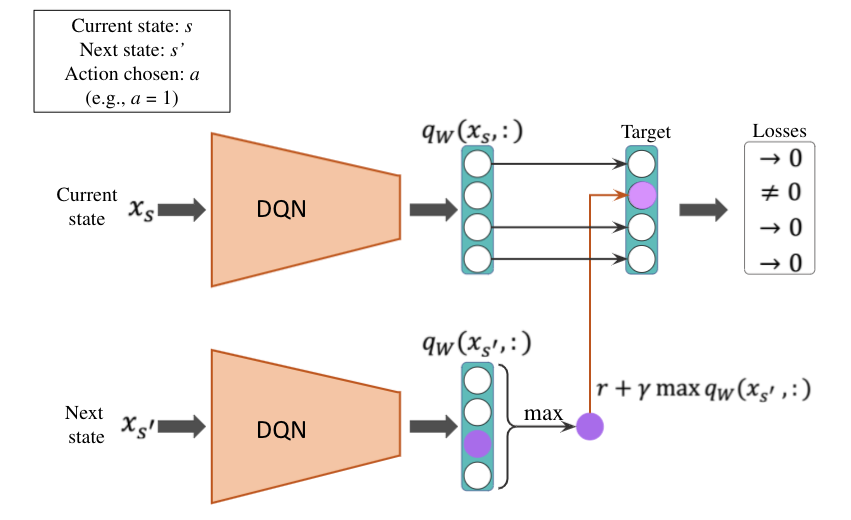

In [17]:
Image(filename='figures/19_12.png', width=600)

## Implementing a deep Q-learning algorithm

In [ ]:
# coding: utf-8

# Python Machine Learning, PyTorch Edition by Sebastian Raschka (https://sebastianraschka.com), Yuxi (Hayden) Liu
# (https://www.mlexample.com/) & Vahid Mirjalili (http://vahidmirjalili.com), Packt Publishing Ltd. 2021
#
# Code Repository: https://github.com
#
# Code License: MIT License (https://github.com/ /LICENSE.txt)

#################################################################################
# Chapter 19 - Reinforcement Learning for Decision Making in Complex Environments
#################################################################################

# Script: carpole/main.py

import gym
import numpy as np
import torch
import torch.nn as nn
import random
import matplotlib.pyplot as plt
from collections import namedtuple
from collections import deque

np.random.seed(1)
torch.manual_seed(1)

Transition = namedtuple(
    'Transition', ('state', 'action', 'reward',
                   'next_state', 'done'))


class DQNAgent:
    def __init__(
            self, env, discount_factor=0.95,
            epsilon_greedy=1.0, epsilon_min=0.01,
            epsilon_decay=0.995, learning_rate=1e-3,
            max_memory_size=2000):
        self.env = env
        self.state_size = env.observation_space.shape[0]
        self.action_size = env.action_space.n

        self.memory = deque(maxlen=max_memory_size)

        self.gamma = discount_factor
        self.epsilon = epsilon_greedy
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.lr = learning_rate
        self._build_nn_model()

    def _build_nn_model(self):
        self.model = nn.Sequential(nn.Linear(self.state_size, 256),
                                   nn.ReLU(),
                                   nn.Linear(256, 128),
                                   nn.ReLU(),
                                   nn.Linear(128, 64),
                                   nn.ReLU(),
                                   nn.Linear(64, self.action_size))

        self.loss_fn = nn.MSELoss()
        self.optimizer = torch.optim.Adam(
            self.model.parameters(), self.lr)

    def remember(self, transition):
        self.memory.append(transition)

    def choose_action(self, state):
        if np.random.rand() <= self.epsilon:
            return np.random.choice(self.action_size)
        with torch.no_grad():
            q_values = self.model(torch.tensor(state, dtype=torch.float32))[0]
        return torch.argmax(q_values).item()  # returns action

    def _learn(self, batch_samples):
        batch_states, batch_targets = [], []
        for transition in batch_samples:
            s, a, r, next_s, done = transition

            with torch.no_grad():
                if done:
                    target = r
                else:
                    pred = self.model(torch.tensor(next_s, dtype=torch.float32))[0]
                    target = r + self.gamma * pred.max()

                target_all = self.model(torch.tensor(s, dtype=torch.float32))[0]
                target_all[a] = target

            batch_states.append(s.flatten())
            batch_targets.append(target_all)
            self._adjust_epsilon()

        self.optimizer.zero_grad()
        pred = self.model(torch.tensor(batch_states, dtype=torch.float32))

        loss = self.loss_fn(pred, torch.stack(batch_targets))
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def _adjust_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def replay(self, batch_size):
        samples = random.sample(self.memory, batch_size)
        return self._learn(samples)


def plot_learning_history(history):
    fig = plt.figure(1, figsize=(14, 5))
    ax = fig.add_subplot(1, 1, 1)
    episodes = np.arange(len(history)) + 1
    plt.plot(episodes, history, lw=4,
             marker='o', markersize=10)
    ax.tick_params(axis='both', which='major', labelsize=15)
    plt.xlabel('Episodes', size=20)
    plt.ylabel('# Total Rewards', size=20)
    plt.show()


# General settings
EPISODES = 200
batch_size = 32
init_replay_memory_size = 500

if __name__ == '__main__':
    env = gym.make('CartPole-v1')
    agent = DQNAgent(env)
    state = env.reset()
    state = np.reshape(state, [1, agent.state_size])

    # Filling up the replay-memory
    for i in range(init_replay_memory_size):
        action = agent.choose_action(state)
        next_state, reward, done, _ = env.step(action)
        next_state = np.reshape(next_state, [1, agent.state_size])
        agent.remember(Transition(state, action, reward,
                                  next_state, done))
        if done:
            state = env.reset()
            state = np.reshape(state, [1, agent.state_size])
        else:
            state = next_state

    total_rewards, losses = [], []
    for e in range(EPISODES):
        state = env.reset()
        if e % 10 == 0:
            env.render()
        state = np.reshape(state, [1, agent.state_size])
        for i in range(500):
            action = agent.choose_action(state)
            next_state, reward, done, _ = env.step(action)
            next_state = np.reshape(next_state, [1, agent.state_size])
            agent.remember(Transition(state, action, reward,
                                      next_state, done))
            state = next_state
            if e % 10 == 0:
                env.render()
            if done:
                total_rewards.append(i)
                print(f'Episode: {e}/{EPISODES}, Total reward: {i}')
                break
            loss = agent.replay(batch_size)
            losses.append(loss)
    plot_learning_history(total_rewards)


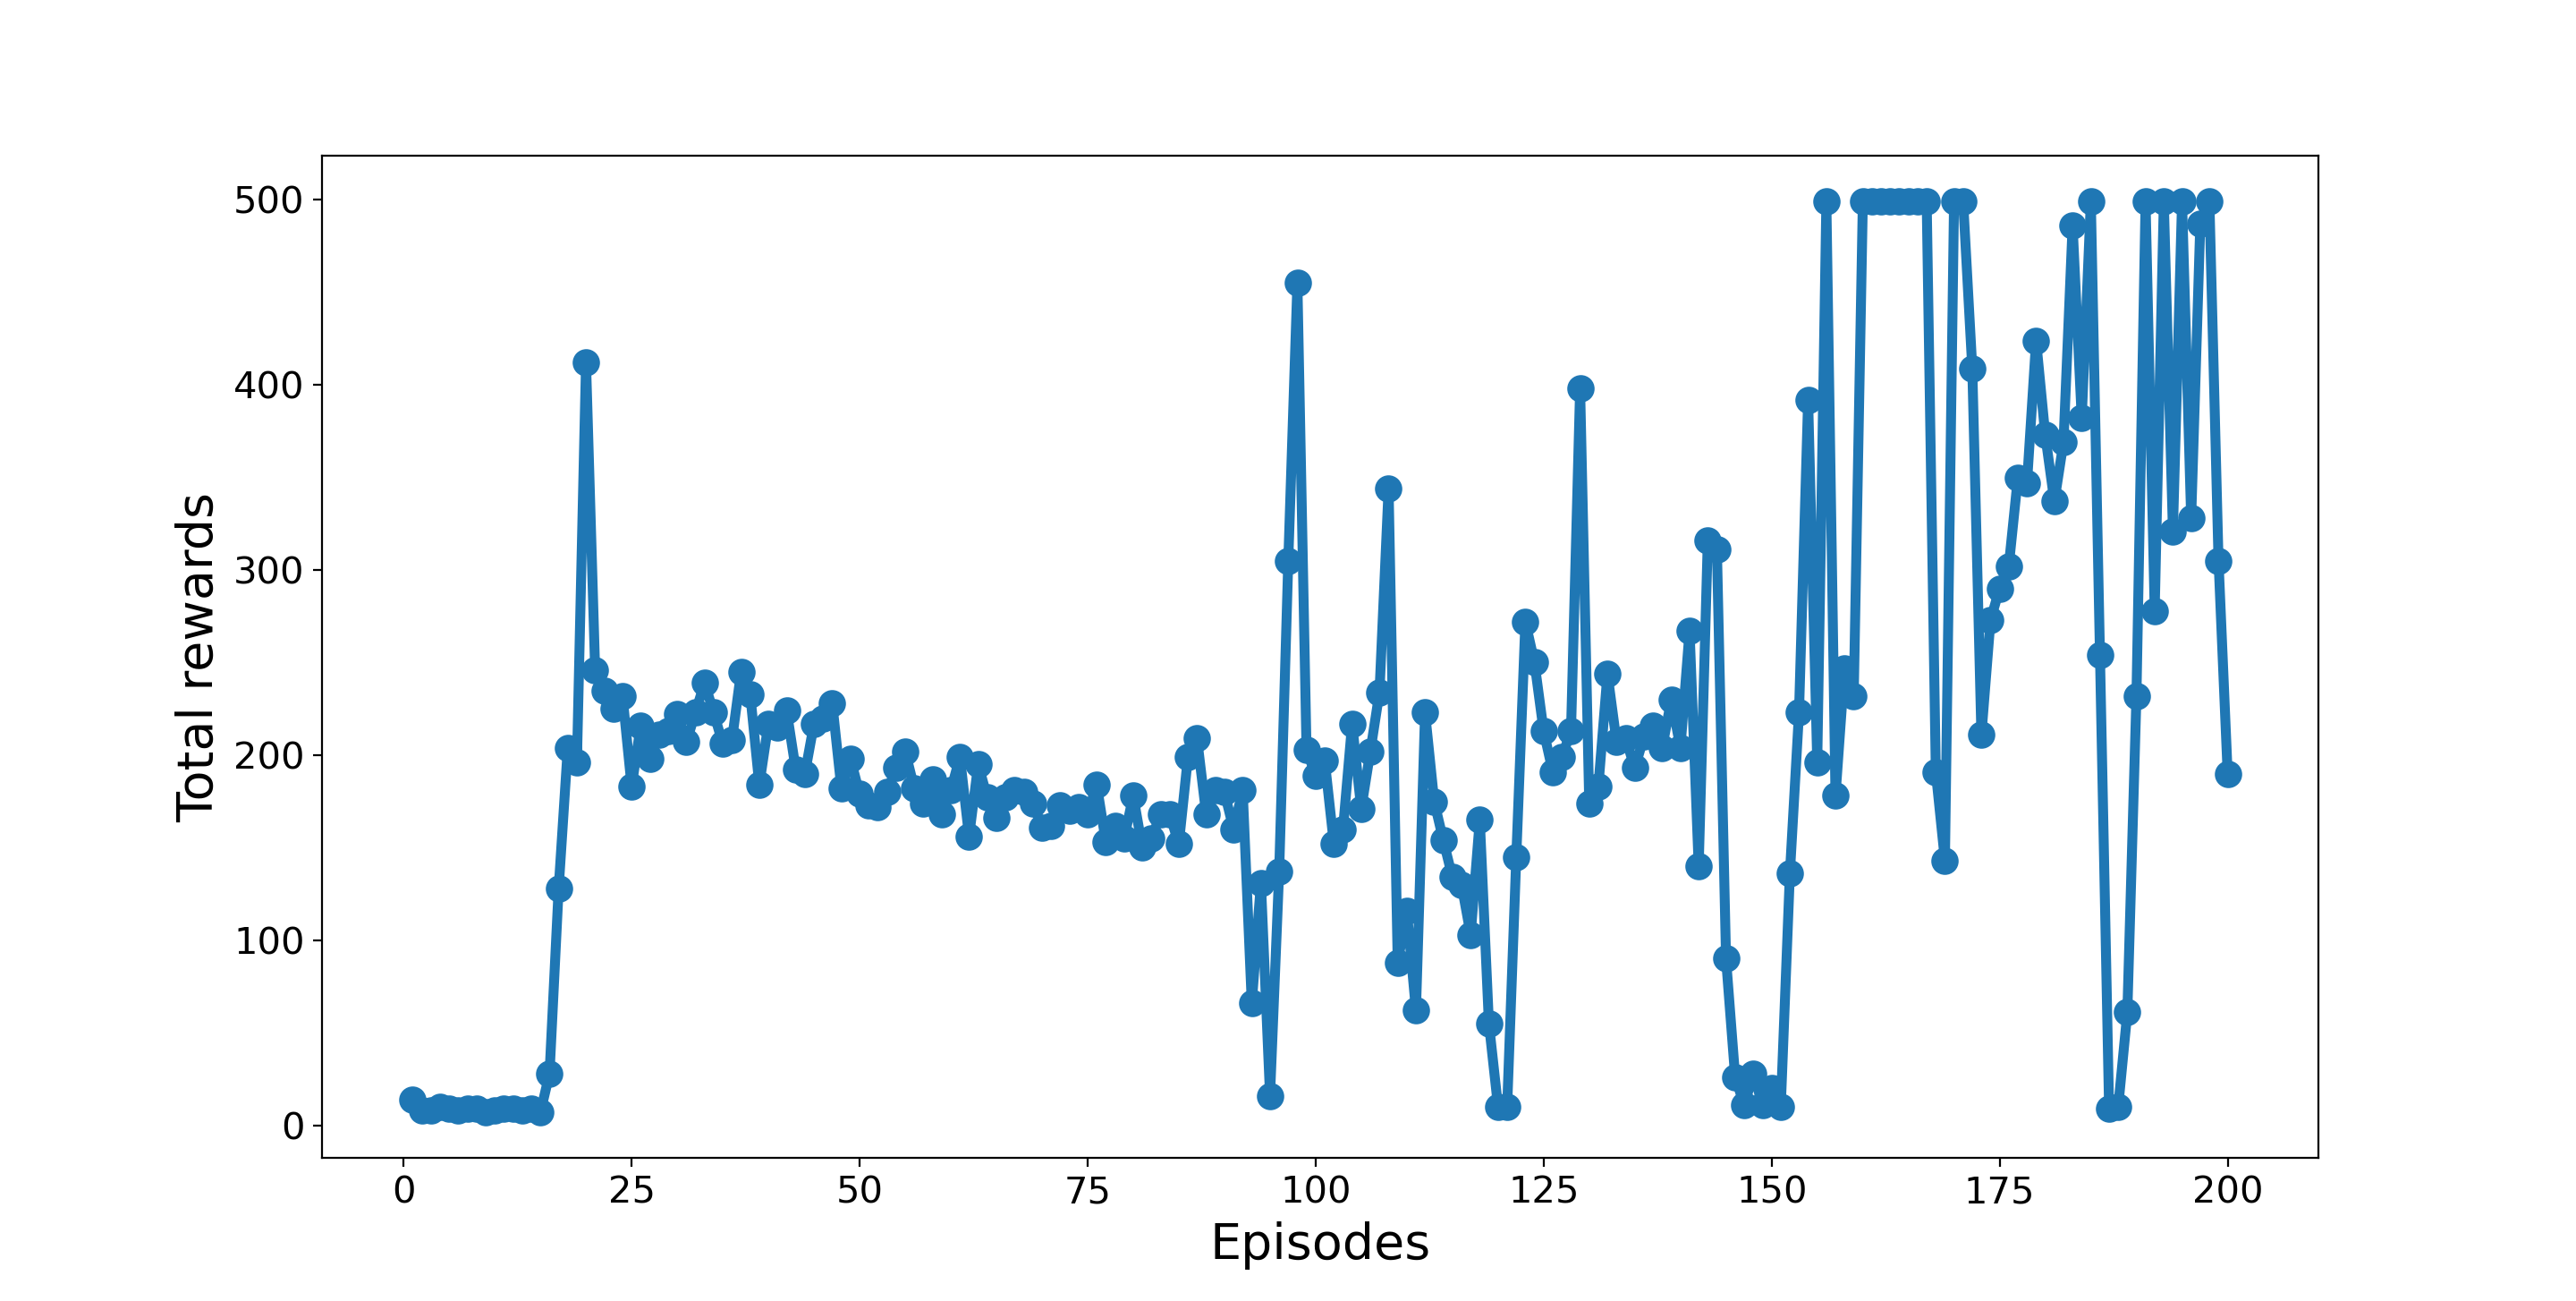

In [19]:
Image(filename='figures/19_13.png', width=600)